## PROVA SCRITTA BIG DATA 2

### Es. 1

Si consideri il data set CIFAR10 che contiene un training set di 50.000 immagini a colori aventi dimensione 32x32 e articolate in 10 categorie diverse. Il test set è costituito da 10.000 immagini di test con le stesse dimensioni e le stesse etichette di classe.

In [5]:
#IMPORT INIZIALI
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange # Modificato per Jupyter Notebook
from inspect import signature

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# --- CONFIGURAZIONI INIZIALI E DEVICE ---
cartella_dati = './cifar-10-batches-py' # Assicurati che la cartella sia nella stessa directory del notebook
dispositivo = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Stiamo usando il dispositivo: {dispositivo}")

# --- FUNZIONI UTILITY (Ex torchnn.py) ---
config = {
    "learning_rate": 1e-3,
    "batch_size": 64,
    "epochs": 20,
    "patience": 5,
    "min_delta": 0.01,
    "momentum": 0.9,
    "nesterov": True,
    "train_loss": nn.CrossEntropyLoss(),
    "test_loss": nn.NLLLoss(),
    "metrics": [precision_score, recall_score, f1_score],
    "metric_average": 'macro'
}

def make_dataloaders(train_data, val_data, test_data, batch=config["batch_size"], prefetch=None, no_pagemem=True):  #prima "prefetch=12"
    # NOTA: se su Windows Jupyter dà problemi, imposta num_workers=0
    workers = 0  #prima 2
    train_dataloader = DataLoader(train_data, batch_size=batch, shuffle=True, num_workers=workers, prefetch_factor=prefetch, pin_memory=no_pagemem)
    val_dataloader = DataLoader(val_data, batch_size=batch, shuffle=True, num_workers=workers, prefetch_factor=prefetch, pin_memory=no_pagemem)
    test_dataloader = DataLoader(test_data, batch_size=batch, shuffle=False, num_workers=workers, prefetch_factor=prefetch, pin_memory=no_pagemem)
    for X, y in test_dataloader:
        print(f"Shape e tipo dei campioni: {X.shape}, {X.dtype}")
        print(f"Shape e tipo delle etichette: {y.shape} {y.dtype}")
        break
    return train_dataloader, val_dataloader, test_dataloader

class EarlyStopping:
    def __init__(self, patience=config["patience"], min_delta=config["min_delta"]):  #patience (int): numero epoche di pazienza, min_delta (float): incremento minimo della loss di validazione
        self.patience = patience
        self.min_delta = min_delta              
        self.counter = 0                        
        self.early_stop = False                 
        self.min_validation_loss = torch.inf  # valore corrente ottimo della loss di validazione

    def __call__(self, validation_loss):
        if (validation_loss + self.min_delta) >= self.min_validation_loss:  # la loss di validazione non decresce
            self.counter += 1  # incrementiamo il contatore delle epoche di pazienza
            if self.counter >= self.patience:
                self.early_stop = True
        else:  # c'è un miglioramento della loss
            self.min_validation_loss = validation_loss  # consideriamo la loss corrente come nuova loss ottimale
            self.counter = 0  # e azzeriamo il contatore

def train_loop(model, dataloader, optimizer, device, pbar, loss_fn=config["train_loss"]):  #loss_fn: loss di addestramento di torchnn, di default a config["train_loss"]
    num_batches = len(dataloader)
    epoch_loss = 0.0
    model.train()  #modello in modalità di training
    for _, (X, y) in zip(pbar,dataloader):      
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()                   
        logits = model(X)
        batch_loss = loss_fn(logits, y)
        epoch_loss += batch_loss.item()
        batch_loss.backward()             
        optimizer.step()                  
    return epoch_loss/num_batches

def eval_loop(model, dataloader, device, loss_fn=config["test_loss"], metrics=config["metrics"], average=config["metric_average"]):
    model.eval()  #modello in modalità di visualizzazione
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, accuracy = 0.0, 0

    y_true, y_pred = [], []

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()

            # L'accuracy sul batch si calcola creando il tensore di dimensione pari al batch
            # per cui i massimi argomenti di ogni predizione sono uguali alla classe predetta
            # per il singolo campione, poi convertendo questo tensore di booleani in un vettore
            # binario di tipo float, sommando i valori 1 ed estraendo lo scalare contenuto nel tensore risultato
            accuracy += (pred.argmax(1) == y).type(torch.float).sum().item()

            y_true.extend(y.cpu().numpy())
            y_pred.extend(pred.argmax(1).cpu().numpy())

    test_loss /= num_batches
    accuracy /= size            
    epoch_metrics = {}  #dizionario delle metriche per epoca
    for metric in metrics:
        epoch_metrics[metric.__name__] = metric(y_true, y_pred, average=average) if 'average' in signature(metric).parameters.keys() else metric(y_true, y_pred)
    return test_loss, accuracy, epoch_metrics

def train_test(model,
               optimizer,
               device, 
               train_dataloader, 
               test_dataloader, 
               epochs=config["epochs"], 
               train_loss_fn=config["train_loss"], 
               test_loss_fn=config["test_loss"], 
               early_stopping=None, 
               val_dataloader=None, 
               scheduler=None, 
               metrics=config["metrics"], 
               average=config["metric_average"]):
    
    train_loss, validation_loss, test_loss, accuracy = [], [], [], []
    test_metrics = {}   
    for metric in metrics:
        test_metrics[metric.__name__] = []  # dizionario delle liste dei valori delle metriche di test epoca per epoca
    num_batches = len(train_dataloader.batch_sampler) 

    for epoch in range(1,epochs+1):  # Ciclo di addestramento con early stopping
        pbar = trange(num_batches)
        pbar.set_description(desc='Epoch {:4d}'.format(epoch))
        epoch_train_loss = train_loop(model, train_dataloader, optimizer, device, pbar, loss_fn=train_loss_fn)
        train_loss.append(epoch_train_loss)

        if val_dataloader != None:  # validation se è presente val_dataloader
                epoch_validate_loss, _, _ = eval_loop(model, val_dataloader, device, loss_fn=test_loss_fn, metrics=metrics, average=average)
                validation_loss.append(epoch_validate_loss)

        epoch_test_loss, epoch_accuracy, epoch_metrics = eval_loop(model, test_dataloader, device, loss_fn=test_loss_fn, metrics=metrics, average=average)
        test_loss.append(epoch_test_loss)
        accuracy.append(epoch_accuracy)
        
        for metric in metrics: 
            test_metrics[metric.__name__].append(epoch_metrics[metric.__name__])

        val_str = f'Validation loss: {epoch_validate_loss:6.4f}\n' if val_dataloader != None else ' '
        print(f"Train loss: {epoch_train_loss:6.4f}\n{val_str}Test loss: {epoch_test_loss:6.4f} Accuracy: {epoch_accuracy:6.2f}\nMetrics: ", end='')
        for label, metric in epoch_metrics.items(): 
            print(f'{label}: {metric:6.2f} ', end=' ')
        print("\n")

        if early_stopping != None:  #early stopping
            #if hasattr(early_stopping, 'controlla_e_salva'):
            #    early_stopping.controlla_e_salva(epoch_validate_loss, model, optimizer, epoch)
            #else:
            early_stopping(epoch_validate_loss)
            if early_stopping.early_stop: 
                print("Early Stopping innescato!")
                break

        if scheduler != None: 
            scheduler.step()

    return train_loss, validation_loss, test_loss, accuracy, test_metrics

def save_model(net, optimizer, current_epoch, train_loss, val_loss, test_loss, accuracy, metrics, path):
    to_save = {'epoch': current_epoch,
               'model_state_dict': net.state_dict(), 
               'optimizer_state_dict': optimizer.state_dict(), 
               'training_loss': train_loss, 
               'validation_loss': val_loss, 
               'test_loss': test_loss, 
               'accuracy': accuracy}
    to_save.update(metrics)
    torch.save(to_save, path)

"""
def load_model(path, model, optimizer, device = None):
    #Ricarichiamo il dizionario e restituiamo la tupla delle informazioni. La rete e l'ottimizzatore devono essere inizializzati prima chiamare la funzione

    #Args:
    #    path (os.path): percorso completo del file del modello
    #    model (torch.nn.Module): modello inizializzato
    #    optimizer (torch.optim.Optimizer): ottimizzatore inizializzato
    #    device (torch.device or int or str): device di caricamento del modello. Defaults to None.

    #Returns:
    #    tuple[torch.nn.Module, torch.optim.Optimizer, Any]: tupla contenente il modello, l'ottimizzatore e tutto lo stato conservato da ``save_model()``


    # Se il device è specificato e non è la CPU, allora muoviamo il modello sul device
    if device != None and device != 'cpu':
        model.to(device)

    # carichiamo il model checkpoint
    checkpoint = torch.load(path)

    # inizializziamo lo stato del modello e dell'ottimizzatore
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    # restituiamo tutte le informazioni in una tupla
    return (model,
            optimizer,
            checkpoint
            )
"""
            
def displayLosses(train_loss, test_loss, validation_loss):
    epochs = range(1, len(train_loss)+1)
    plt.plot(epochs, train_loss, label='training loss')
    plt.plot(epochs,validation_loss, label='validation loss')
    plt.plot(epochs, test_loss, label='test loss')
    plt.legend(loc='upper right')
    plt.title("Loss di addestramento")
    plt.ylim(0, max(max(train_loss), max(validation_loss))*1.2)
    plt.show()
    
def displayMetrics(accuracy, metrics):
    epochs = range(1, len(accuracy)+1) 
    plt.plot(epochs, accuracy, label="train acc.")
    for label, metric in metrics.items(): plt.plot(epochs, metric, label=label)
    plt.legend(loc='lower right')
    plt.title("Metriche")
    plt.ylim(0,1)
    plt.show()

Stiamo usando il dispositivo: cuda


1. Caricare il data set tramite ...
- Download direttamente tramite Torch, che genera un dataset

- Imputazione dati mancanti
- Scaling (normalizzare tutto in 0/1, ecc.)

- Implementazione sia per il training sia per il validation set


OSS. Una rete con 1D corrisponde a un tensore tridimensionale

1. Caricare il dataset direttamente dalla sua home page:
https://www.cs.toronto.edu/~kriz/cifar.html ed espungere randomicamente
un validation set pari al 10% dei dati di training, mantenendo il restante 90%
come training set vero e proprio. Effettuare una data augmentation tramite
torchvision usando mirroring orizzontali e verticali casuali nonché
traslazioni e rotazioni casuali in un range di ± 5 pixel in x e y e ± 10°
rispettivamente.

In [3]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Subset, DataLoader
import numpy as np

#####################################################################################################################################################################
#Estrazione dei valori di media e dev. std. standardizzati per CIFAR10 (vanno usati nella Normalize)

# 1. Carichiamo solo il Training Set convertendolo in Tensore (range [0.0, 1.0])
# NON applichiamo la normalizzazione o la data augmentation qui!
#Usando l'intero dataset per normalizzare i dati, le info su colori e illuminazione del test set "inquinerebbero" i dati di training
transform = transforms.ToTensor()
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

# 2. Usiamo un DataLoader per iterare i dati in lotti
# Usiamo un batch_size grande per velocizzare il calcolo e num_workers se hai una CPU multicore
loader = DataLoader(train_dataset, batch_size=1024, shuffle=False)

# Inizializziamo tre tensori a zero per accumulare le somme dei canali RGB
psum = torch.tensor([0.0, 0.0, 0.0])
psum_sq = torch.tensor([0.0, 0.0, 0.0])

for images, _ in loader:
    # images ha dimensione: (batch_size, canali, altezza, larghezza) -> (N, 3, 32, 32)
    # Sommiamo su tutte le dimensioni tranne quella dei canali (dimensione 1)
    # Quindi sommiamo su batch_size(0), altezza(2) e larghezza(3)
    psum += images.sum(dim=[0, 2, 3])
    psum_sq += (images ** 2).sum(dim=[0, 2, 3])

# 3. Calcoliamo i totali
# Numero totale di pixel per ogni canale: (num_immagini * altezza * larghezza)
# Per CIFAR-10: 50000 immagini * 32 * 32 = 51.200.000 pixel per canale
count = len(train_dataset) * 32 * 32

# 4. Applichiamo le formule statistiche
# Media = Somma dei pixel / numero totale dei pixel
total_mean = psum / count

# Varianza = (Somma dei quadrati / count [Valor quadratico medio]) - (Media al quadrato)
total_var = (psum_sq / count) - (total_mean ** 2)

# Deviazione Standard = Radice quadrata della varianza
total_std = torch.sqrt(total_var)

print(f"Media (Mean): {total_mean}")
print(f"Dev. Standard (Std): {total_std}")
#####################################################################################################################################################################

# Impostiamo un seed per la riproducibilità dello split randomico
np.random.seed(42)  #così il validation set sarà identico ad ogni esecuzione

# 1. Definizione della Data Augmentation per il Training Set
# Le immagini CIFAR10 sono 32x32 pixel. PyTorch calcola la traslazione come frazione della dimensione dell'immagine. 
# Pertanto, 5 pixel equivalgono a 5/32 (0.15625).
train_transform = transforms.Compose([  #Compose impacchetta la lista di trasformazioni separate e restituisce un'unica funzione (necessaria per creare il dataset)
    #nella Compose l'ordine delle operazioni da effettuare è fondamentale
    transforms.RandomHorizontalFlip(p=0.5), # Mirroring orizzontale casuale
    transforms.RandomVerticalFlip(p=0.5),   # Mirroring verticale casuale
    transforms.RandomAffine(  #Random....Flip e RandomAffine lavorano su immagini in formato PIL (Python Imaging Library)
        degrees=[-10, 10],                  # Rotazione casuale nel range [-10°, +10°]
        translate=(5/32, 5/32)              # Traslazione casuale in x e y di +-5 pixel
    ),
    transforms.ToTensor(),  #converte l'immagine PIL in un Tensore PyTorch e scala i valori da 0-255 a 0.0-1.0
    # Normalizzazione con i valori medi e di deviazione standard standardizzati per CIFAR-10
    transforms.Normalize(total_mean, total_std) 
])

# 2. Definizione delle trasformazioni per Validation e Test Set
# Nessuna data augmentation, solo conversione in tensore e normalizzazione
val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(total_mean, total_std)
])

# 3. Caricamento dei Dataset
# Carichiamo due istanze del dataset di training per poter applicare le trasformazioni corrette ai rispettivi subset.
full_train_dataset_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
full_train_dataset_clean = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=val_test_transform)

# 4. Calcolo degli indici per lo split 90% / 10%
num_train = len(full_train_dataset_aug) # 50.000
indices = list(range(num_train))
np.random.shuffle(indices)              # Mescoliamo casualmente gli indici
split_idx = int(np.floor(0.1 * num_train)) # Il 10% corrisponde a 5.000 immagini

# Espungiamo il 10% per la validation e teniamo il 90% per il training
val_idx, train_idx = indices[:split_idx], indices[split_idx:]

# 5. Creazione dei Subset definitivi
# Al training set (45.000 immagini) applichiamo l'istanza con data augmentation
train_dataset = Subset(full_train_dataset_aug, train_idx)

# Al validation set (5.000 immagini) applichiamo l'istanza "pulita"
val_dataset = Subset(full_train_dataset_clean, val_idx)

# 6. Caricamento del Test Set (10.000 immagini)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=val_test_transform)

# --- Verifica delle dimensioni ---
print(f"Dimensioni Training Set: {len(train_dataset)} immagini")
print(f"Dimensioni Validation Set: {len(val_dataset)} immagini")
print(f"Dimensioni Test Set: {len(test_dataset)} immagini")

Media (Mean): tensor([0.4914, 0.4822, 0.4465])
Dev. Standard (Std): tensor([0.2470, 0.2435, 0.2616])
Dimensioni Training Set: 45000 immagini
Dimensioni Validation Set: 5000 immagini
Dimensioni Test Set: 10000 immagini


In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pickle
import os

def unpickle(file):
    with open(file, 'rb') as fo:
        dizionario = pickle.load(fo, encoding='bytes')
    return dizionario

class MioCIFAR10Completo(Dataset):
    def __init__(self, cartella_dataset, train=True, transform=None):
        self.transform = transform
        dati_grezzi = []
        self.etichette = []
        
        if train:
            nomi_file = ['data_batch_1', 'data_batch_2', 'data_batch_3', 'data_batch_4', 'data_batch_5']
        else:
            nomi_file = ['test_batch']
            
        for nome_file in nomi_file:
            percorso_completo = os.path.join(cartella_dataset, nome_file)
            batch = unpickle(percorso_completo)
            dati_grezzi.append(batch[b'data'])
            self.etichette.extend(batch[b'labels'])
            
        dati_uniti = np.vstack(dati_grezzi)
        self.dati = dati_uniti.reshape(-1, 3, 32, 32).astype(np.float32) / 255.0
        self.dati_piatti = dati_uniti.reshape(-1, 3072).astype(np.float32) / 255.0  

    def __len__(self):
        return len(self.dati)

    def __getitem__(self, idx):
        immagine = self.dati[idx]
        etichetta = self.etichette[idx]
        immagine_tensor = torch.from_numpy(immagine)
        if self.transform:
            immagine_tensor = self.transform(immagine_tensor)
        return immagine_tensor, etichetta

class ApplicaTrasformazione(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        immagine, etichetta = self.subset[index]
        if self.transform:
            immagine = self.transform(immagine)
        return immagine, etichetta
        
    def __len__(self):
        return len(self.subset)

# --- ESECUZIONE PUNTO 1 ---
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),      
    transforms.RandomVerticalFlip(),        
    transforms.RandomAffine(                
        degrees=[-10, 10],                  
        translate=(5/32, 5/32)              
    )
])

train_set_init = MioCIFAR10Completo(cartella_dati, train=True, transform=None)
test_set_init = MioCIFAR10Completo(cartella_dati, train=False, transform=None)

# Split 90% (45.000) e 10% (5.000)
train_subset, val_subset = random_split(train_set_init, [45000, 5000])

# Applichiamo la trasformazione SOLO al train set puro
train_set_augmented = ApplicaTrasformazione(train_subset, transform=train_transform)
val_set = ApplicaTrasformazione(val_subset, transform=None)
test_set = ApplicaTrasformazione(test_set_init, transform=None)

print(f"Dimensione Training Set: {len(train_set_augmented)}")
print(f"Dimensione Validation Set: {len(val_set)}")
print(f"Dimensione Test Set: {len(test_set)}")

Dimensione Training Set: 45000
Dimensione Validation Set: 5000
Dimensione Test Set: 10000


2. Implementare un classificatore dei punti del data set processato al punto 1, utilizzando un algoritmo di Gradient Boosting con la seguente griglia di ricerca, usando una cross-validation a 10 fold:
- Learning rate: 0.01, 0.1, 0.2
- N.stimatori: 50, 100, 200
- Min. campioni per foglia: 10, 20 , 50
Stampare l'accuracy del miglior modello in addestramento e predizione


In [3]:
print("--- Avvio Gradient Boosting ---")
# Usiamo i dati "piatti" estratti dal dataset originale (senza Data Augmentation)
X_train_ml = train_set_init.dati_piatti
y_train_ml = np.array(train_set_init.etichette)
X_test_ml = test_set_init.dati_piatti
y_test_ml = np.array(test_set_init.etichette)

param_grid = {
    'learning_rate': [0.1, 0.2],  #tolto 0.01
    'max_iter': [50, 100],  #tolto 200
    'min_samples_leaf': [20, 50]  #tolto 10
}

clf = HistGradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(
    clf, 
    param_grid, 
    cv=3,  #originariamente 10
    n_jobs=-1, 
    verbose=3
)

# ATTENZIONE: Il fit completo richiede molto tempo. 
# Per una prova veloce, è impostato su un subset di 1000 immagini. 
# Per addestrare su tutto il dataset, commentare la prima riga e scommentare la seconda.
grid_search.fit(X_train_ml[:100], y_train_ml[:100]) 
# grid_search.fit(X_train_ml, y_train_ml)

best_gb = grid_search.best_estimator_
print(f"Migliori Parametri GB trovati: {grid_search.best_params_}")

acc_train_clf = accuracy_score(y_train_ml, best_gb.predict(X_train_ml))
acc_test_clf = accuracy_score(y_test_ml, best_gb.predict(X_test_ml))
print(f"GB - Accuracy Addestramento: {acc_train_clf:.4f}")
print(f"GB - Accuracy Predizione (Test): {acc_test_clf:.4f}")

--- Avvio Gradient Boosting ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Migliori Parametri GB trovati: {'learning_rate': 0.1, 'max_iter': 50, 'min_samples_leaf': 50}
GB - Accuracy Addestramento: 0.1657
GB - Accuracy Predizione (Test): 0.1598


3. Implementare una piccola rete neurale convoluzionale bidimensionale in PyTorch, utilizzando la semplice API torchnn.py, per eseguire la classificazione multiclasse. La rete dovrà avere un adeguato numero di layer convoluzionali bidimensionali e, nella parte densa, dropout 0.2. Si utilizzi per l’addestramento l’ottimizzatore SGD con momento di Nesterov e learning rate dercescente esponenzialmente a partire da 0.01. Implementare una callback di early stopping con una pazienza sulla validation loss di 5 epoche e un incremento minimo di miglioramento pari a 0.01; implementare anche una callback di model checkpoint per il salvataggio del solo miglior modello rispetto alla minima validation loss.

In [6]:
class Cifar10CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Layer convoluzionali
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # Parte densa (Fully Connected) con Dropout 0.2 richiesto
        self.fc1 = nn.Linear(64 * 8 * 8, 256)  #256 sorta di standard
        self.dropout = nn.Dropout(0.2)  # Dropout aggiunto come richiesto
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x) 
        x = self.fc2(x)
        return x
    
class CheckpointEarlyStopping(EarlyStopping):
    def __init__(self, patience, min_delta, path_salvataggio):
        super().__init__(patience, min_delta)
        self.path_salvataggio = path_salvataggio
        
    def controlla_e_salva(self, validation_loss, model, optimizer, epoch):
        super().__call__(validation_loss) # Richiama il check dell'early stopping
        if validation_loss == self.min_validation_loss:  # Se c'è stato un miglioramento (la loss minima è stata appena aggiornata)
            print(f"--> Miglioramento della loss ({validation_loss:.4f}). Salvataggio modello in corso...")
            save_model(model, optimizer, epoch, [], [], [], [], {}, self.path_salvataggio)

# --- ESECUZIONE PUNTO 3 ---
print("Creazione dei DataLoader in corso...")
trainloader, valloader, testloader = make_dataloaders(
    train_data=train_set_augmented,
    val_data=val_set,
    test_data=test_set,
    batch=64 
)

modello = Cifar10CNN().to(dispositivo)

loss_fn = nn.CrossEntropyLoss()
opt = optim.SGD(modello.parameters(), lr=0.01, nesterov=True, momentum=0.9)  #momentum a 0.9 per equaz. di Nesterov, per True deve essere =! 0

scheduler = optim.lr_scheduler.ExponentialLR(opt, gamma=0.9)  #gamma pari al momentum
early_stop_checkpoint = CheckpointEarlyStopping(patience=5, min_delta=0.01, path_salvataggio="best-model.pth")

print("Inizio Addestramento CNN...")
train_loss, val_loss, test_loss, accuracy, test_metrics = train_test(
    model=modello,
    optimizer=opt,
    device=dispositivo,
    train_dataloader=trainloader,
    val_dataloader=valloader,
    test_dataloader=testloader,
    epochs=30,  #limite massimo per cui il programma può girare, dovuto all'early stopping
    train_loss_fn=loss_fn,
    test_loss_fn=loss_fn,
    early_stopping=early_stop_checkpoint,
    scheduler=scheduler
)


Creazione dei DataLoader in corso...
Shape e tipo dei campioni: torch.Size([64, 3, 32, 32]), torch.float32
Shape e tipo delle etichette: torch.Size([64]) torch.int64
Inizio Addestramento CNN...


Epoch    1: 100%|██████████| 704/704 [00:29<00:00, 24.00it/s]


Train loss: 2.0043
Validation loss: 1.7741
Test loss: 1.7478 Accuracy:   0.34
Metrics: precision_score:   0.39  recall_score:   0.34  f1_score:   0.31  



Epoch    2: 100%|██████████| 704/704 [00:24<00:00, 28.96it/s]


Train loss: 1.6744
Validation loss: 1.5699
Test loss: 1.5385 Accuracy:   0.44
Metrics: precision_score:   0.46  recall_score:   0.44  f1_score:   0.42  



...

Train loss: 1.0061
Validation loss: 0.9208
Test loss: 0.9215 Accuracy:   0.68
Metrics: precision_score:   0.68  recall_score:   0.68  f1_score:   0.67  



Epoch   29: 100%|██████████| 704/704 [00:29<00:00, 23.90it/s]


Train loss: 1.0053
Validation loss: 0.9028
Test loss: 0.9010 Accuracy:   0.68
Metrics: precision_score:   0.68  recall_score:   0.68  f1_score:   0.68  



Epoch   30: 100%|██████████| 704/704 [00:27<00:00, 25.66it/s]


Train loss: 1.0016
Validation loss: 0.9050
Test loss: 0.8955 Accuracy:   0.69
Metrics: precision_score:   0.69  recall_score:   0.68  f1_score:   0.68  



4. Conservare la lista delle accuracy di addestramento e di test su tutte le epoche del classificatore neurale e stamparne il grafico. Confrontare i risultati del miglior classificatore Gradient Boosting e del classificatore neurale calcolando e stampando, per ciascuno, la matrice di confusione, il valore di accuracy e di loss, la ROC e il valore di AUC per singola classe, calcolati sul test set.

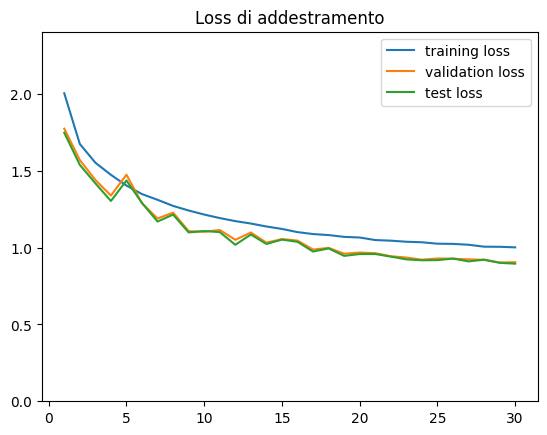

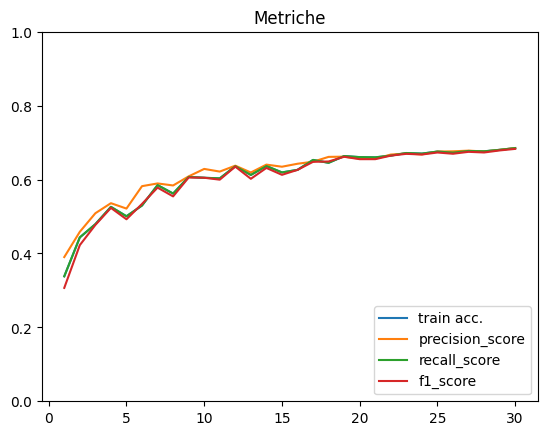

==== CONFRONTO GLOBALE ====
Gradient Boosting - Accuracy: 0.1598
CNN - Accuracy Test: 0.6850 | Loss Test: 0.8955

==== MATRICI DI CONFUSIONE ====
Matrice Confusione GB:
 [[ 37 108 276  98  53  29  38  86  24 251]
 [ 46 256 137 108  40  27  50  60   8 268]
 [ 40 110 200 122 186  59  91  77  11 104]
 [ 26 147 141 180 133  63 104 120   5  81]
 [ 29 108 165 133 227  57  95 121   0  65]
 [ 19 152 153 216 164  38  74 125   6  53]
 [  9 203 108 135 196  48 138  80   1  82]
 [ 24 127 123 120 143  64 176 137   6  80]
 [ 17 177 111 115  31  18  26  37  37 431]
 [ 25 186  93 122  34  45  65  77   5 348]]

Matrice Confusione CNN:
 [[741  18  35  13  31   1   5  16 104  36]
 [ 40 736   5   8   2   4  10  16  32 147]
 [ 68   6 501  65 155  58  76  41  19  11]
 [ 23  11  71 474  79 174  71  56  23  18]
 [ 23   2  54  35 699  21  41 108   8   9]
 [ 15   4  32 202  62 579  21  66  10   9]
 [  3   3  42  64  68  30 768  12   6   4]
 [ 21   2  16  50  81  58   4 753   5  10]
 [ 75  41   8  12  12   7   0

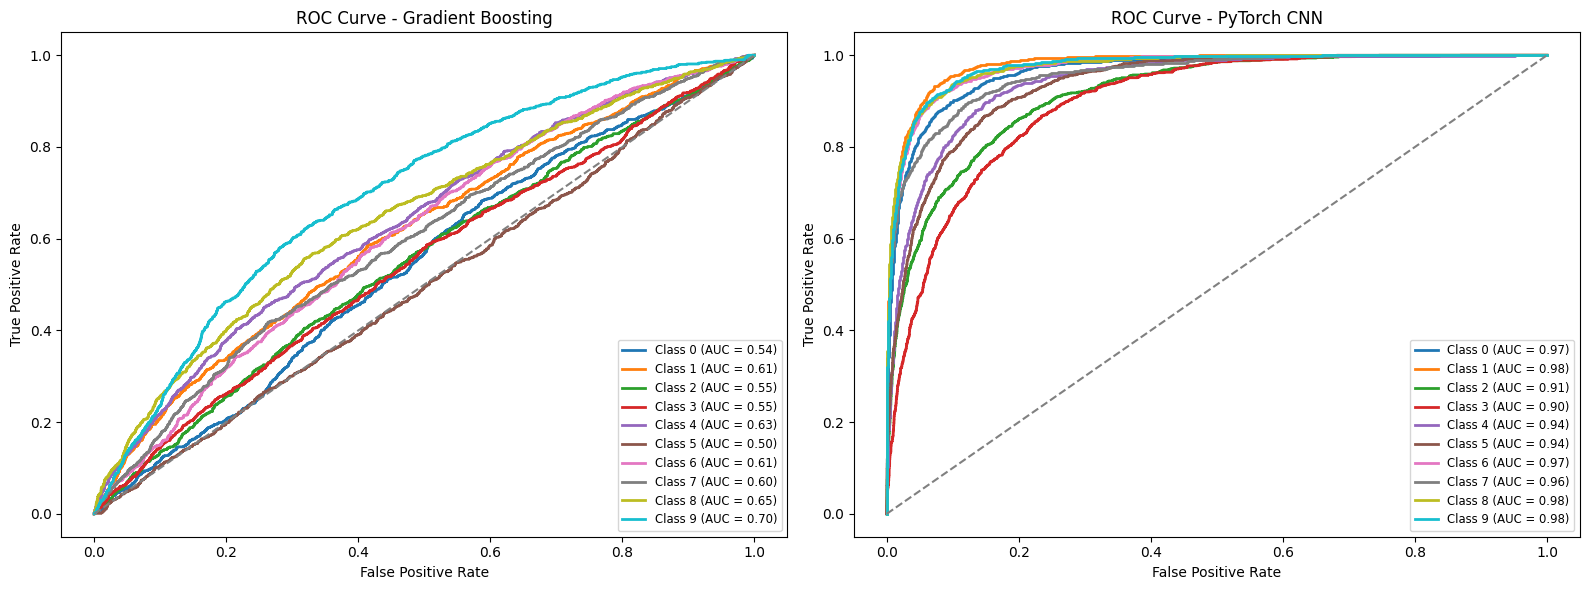

: 

In [ ]:
# 4.1 Plot dell'accuracy e delle loss del classificatore neurale
displayLosses(train_loss, test_loss, val_loss)
displayMetrics(accuracy, test_metrics)

# 4.2 Ottenere predizioni CNN per la matrice di confusione e ROC
modello.eval()
y_true_nn = []
y_pred_nn = []
y_prob_nn = []
loss_totale_nn = 0

with torch.no_grad():
    for X, y in testloader:
        X, y = X.to(dispositivo), y.to(dispositivo)
        logits = modello(X)
        probs = torch.softmax(logits, dim=1)
        loss_totale_nn += loss_fn(logits, y).item()
        
        y_true_nn.extend(y.cpu().numpy())
        y_pred_nn.extend(logits.argmax(1).cpu().numpy())
        y_prob_nn.extend(probs.cpu().numpy())
        
y_true_nn = np.array(y_true_nn)
y_prob_nn = np.array(y_prob_nn)
loss_media_test_nn = loss_totale_nn / len(testloader)

# Confronto metriche globali
print("==== CONFRONTO GLOBALE ====")
print(f"Gradient Boosting - Accuracy: {acc_test_clf:.4f}")
print(f"CNN - Accuracy Test: {accuracy_score(y_true_nn, y_pred_nn):.4f} | Loss Test: {loss_media_test_nn:.4f}")

# Matrici di Confusione
print("\n==== MATRICI DI CONFUSIONE ====")
print("Matrice Confusione GB:\n", confusion_matrix(y_test_ml, best_gb.predict(X_test_ml)))
print("\nMatrice Confusione CNN:\n", confusion_matrix(y_true_nn, y_pred_nn))

# 4.3 Calcolo ROC e AUC per singola classe
y_test_bin = label_binarize(y_test_ml, classes=range(10))
y_prob_gb = best_gb.predict_proba(X_test_ml)

print("\n==== AUC PER SINGOLA CLASSE ====")
# Plottiamo le curve ROC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for i in range(10):
    # Calcolo AUC
    auc_gb = roc_auc_score(y_test_bin[:, i], y_prob_gb[:, i])
    auc_nn = roc_auc_score(y_test_bin[:, i], y_prob_nn[:, i])
    print(f"Classe {i:2d} - AUC GB: {auc_gb:.4f} | AUC CNN: {auc_nn:.4f}")
    
    # Dati per Curve ROC
    fpr_gb, tpr_gb, _ = roc_curve(y_test_bin[:, i], y_prob_gb[:, i])
    fpr_nn, tpr_nn, _ = roc_curve(y_test_bin[:, i], y_prob_nn[:, i])
    
    # Disegno le linee per le classi
    ax1.plot(fpr_gb, tpr_gb, lw=2, label=f'Class {i} (AUC = {auc_gb:.2f})')
    ax2.plot(fpr_nn, tpr_nn, lw=2, label=f'Class {i} (AUC = {auc_nn:.2f})')

# Stile grafici ROC
ax1.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax1.set_title('ROC Curve - Gradient Boosting')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc="lower right", fontsize='small')

ax2.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax2.set_title('ROC Curve - PyTorch CNN')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend(loc="lower right", fontsize='small')

plt.tight_layout()
plt.show()

MAVVAFFANCULO MA ANDATE A CAGARE FROCI DIMME' WOMP WOMP
VALERIO MI CIUCCIA IL DIGLETT QUEL BOOMER
13.000 SONO LE BOFFE CHE VI MERITATE
LA O IN UNIPA STA PER ORGANIZZAZIONE
LA TEORIA E' SOLO ORATORIA, SE VOLEVO FARE ORATORIA ANDAVO A LETTERE